"""
ENVIRONMENT SETUP AND DEPENDENCY LOADING LOGIC:
- Import core data manipulation and numerical processing libraries to support complex matrix operations and time-series handling.
- Configure the execution environment to suppress non-critical warnings and establish global aesthetic parameters for consistent reporting.
"""

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from datetime import datetime
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
# Read the parquet file
df = pd.read_parquet('bookings_data.parquet')

In [4]:
df.head()

,net_bookings_3m | Entity,net_bookings_3m | Segment_A,net_bookings_3m | Segment_B,net_bookings_3m | Segment_C,actual_lead_time | Segment_A,actual_lead_time | Segment_B,actual_lead_time | Segment_C,predicted_lead_time | Segment_A,predicted_lead_time | Segment_B,predicted_lead_time | Segment_C,...,New Orders_Telecommunication Services,Output Prices_Electronic Computing Equipment,Output Prices_Telecommunication Services,Output/Activity_Telecommunication Services,Output/Activity_Electronic Computing Equipment,PMI_Electronic Computing Equipment,Quantity of Purchases_Electronic Computing Equipment,Stocks of Finished Goods_Electronic Computing Equipment,Stocks of Purchases_Electronic Computing Equipment,Suppliers' Delivery Times_Electronic Computing Equipment
datestamp,,,,,,,,,,,,,,,,,,,,,
2013-10-31,2.389716,0.672073,1.296524,0.421119,NaN,NaN,NaN,NaN,NaN,NaN,...,54.478,49.394000,48.117,53.215,55.903000,53.919617,56.373000,50.518800,50.7710,49.306000
2013-11-30,2.621053,0.741342,1.402816,0.476895,0.756077,NaN,NaN,NaN,NaN,NaN,...,53.115,49.114000,48.153,53.523,56.983333,54.822217,57.177000,50.415800,51.8240,46.651000
2013-12-31,2.808476,0.752636,1.554368,0.501472,NaN,NaN,NaN,NaN,NaN,NaN,...,53.744,47.994063,51.380,52.918,52.262000,53.208771,55.774467,48.984000,50.6542,48.315707
2014-01-31,2.555131,0.647301,1.483929,0.423901,NaN,NaN,NaN,NaN,NaN,NaN,...,54.070,48.709000,52.110,51.273,55.997000,53.580003,53.984867,49.097133,48.1350,47.427867
2014-02-28,2.485069,0.626798,1.466182,0.392089,0.278555,NaN,NaN,NaN,NaN,NaN,...,52.449,46.988000,50.862,52.261,52.992000,52.793177,52.629933,49.117133,50.2650,47.700200


In [ ]:
"""
HISTORICAL TREND AND CONTRIBUTION ANALYSIS LOGIC:
- Visualize the 'Total Entity' bookings alongside segments A, B, and C to evaluate the relative scale and contribution of each business unit.
- Analyze longitudinal movements to identify the primary driver of global demand fluctuations across the historical timeline.
- Insight: The Total Entity trajectory mirrors Segment B most closely, suggesting Segment B is the dominant influence on overall corporate booking volume.
"""

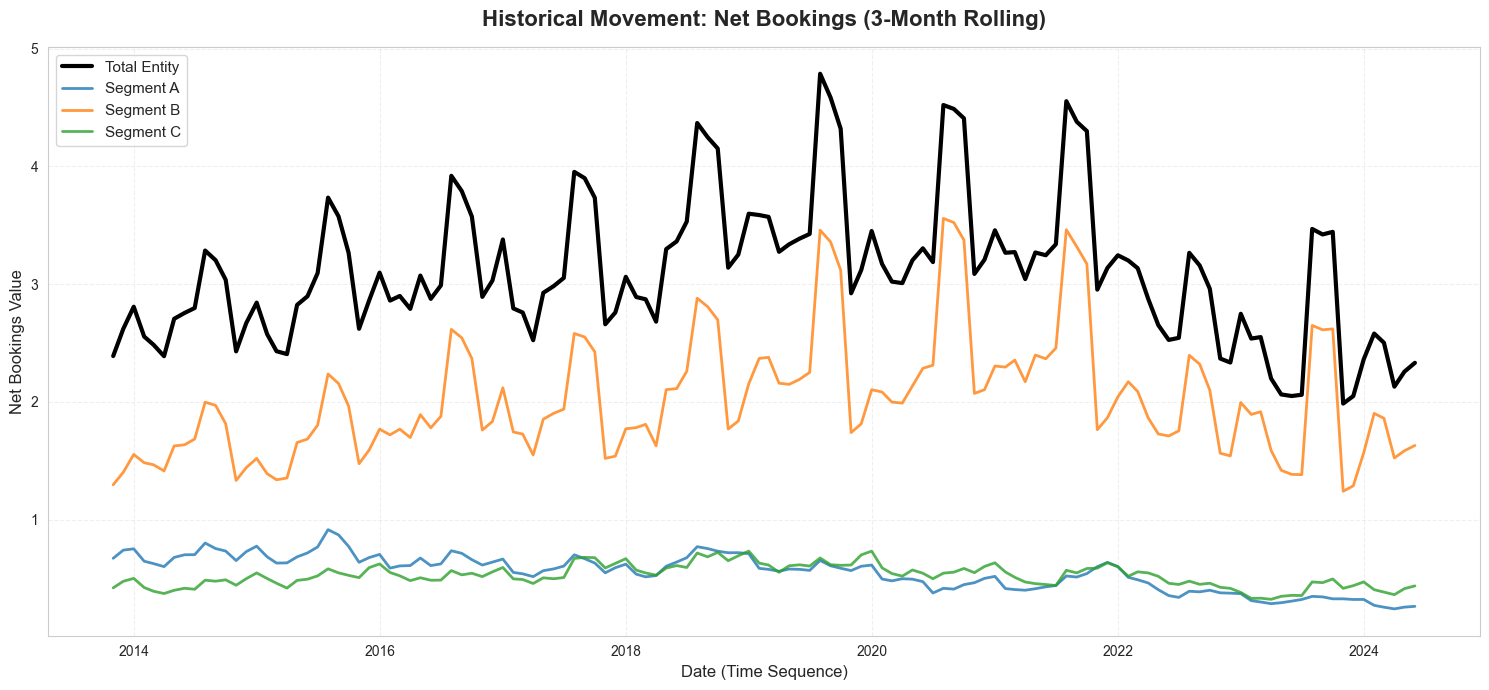

In [5]:
# Define the columns to plot
target_columns = [
    'net_bookings_3m | Entity', 
    'net_bookings_3m | Segment_A', 
    'net_bookings_3m | Segment_B', 
    'net_bookings_3m | Segment_C'
]

# Initialize the plot
plt.figure(figsize=(15, 7))

# Plot the Entity (Total) with a thicker line for emphasis
plt.plot(df.index, df['net_bookings_3m | Entity'], 
         label='Total Entity', color='black', linewidth=3, zorder=5)

# Plot the individual segments
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
segments = ['Segment_A', 'Segment_B', 'Segment_C']

for seg, color in zip(segments, colors):
    col_name = f'net_bookings_3m | {seg}'
    plt.plot(df.index, df[col_name], label=seg.replace('_', ' '), 
             color=color, linewidth=2, alpha=0.8)

# Formatting the visualization
plt.title('Historical Movement: Net Bookings (3-Month Rolling)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date (Time Sequence)', fontsize=12)
plt.ylabel('Net Bookings Value', fontsize=12)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
"""
SEGMENT-SPECIFIC COMPARATIVE ANALYSIS LOGIC:
- Isolate Segment A and Segment C from the broader dataset.
- Insight: While Segment A maintains a higher absolute booking volume, Segment C often exhibits independent fluctuations that are masked when viewed at the aggregate Entity level.
"""

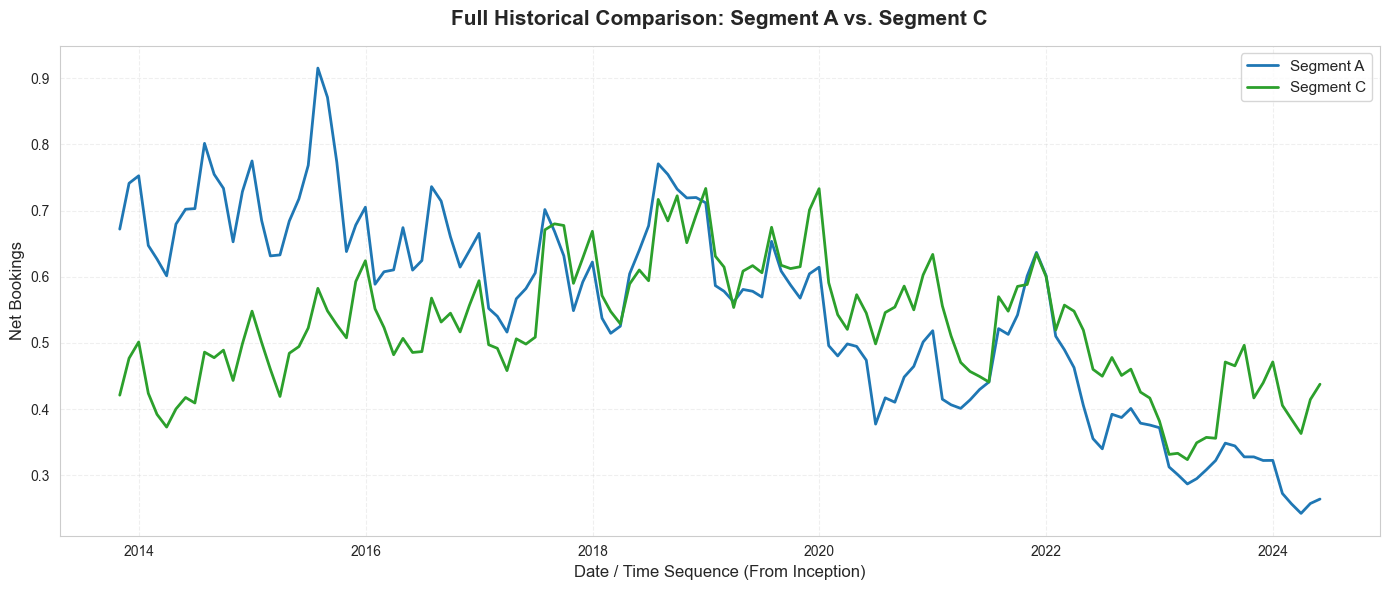

In [7]:
# Define the segments of interest
zoom_cols = ['net_bookings_3m | Segment_A', 'net_bookings_3m | Segment_C']

# Use the full dataframe to start from the first month
df_full_history = df[zoom_cols].sort_index()

# Initialize the plot
plt.figure(figsize=(14, 6))

# Plot Segment A (Full History)
plt.plot(df_full_history.index, df_full_history['net_bookings_3m | Segment_A'], 
         label='Segment A', color='#1f77b4', linewidth=2)

# Plot Segment C (Full History)
plt.plot(df_full_history.index, df_full_history['net_bookings_3m | Segment_C'], 
         label='Segment C', color='#2ca02c', linewidth=2)

# Formatting the visualization
plt.title('Full Historical Comparison: Segment A vs. Segment C', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date / Time Sequence (From Inception)', fontsize=12)
plt.ylabel('Net Bookings', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

# Display the plot
plt.tight_layout()
plt.show()

### Null Value Analysis

In [ ]:
"""
MISSING VALUES VISUALIZATION LOGIC:
- Chronologically sort the dataset by the date index to ensure that missing value patterns are viewed sequentially over time.
- Generate a boolean matrix of null values and transpose it so that features appear on the y-axis and time on the x-axis.
- Render a heatmap visualization to pinpoint exactly when and where data gaps occur within the macroeconomic and internal feature sets.
- Apply descriptive titles and horizontal axis labels to ensure that specific features and time periods are easily identifiable.
"""

'\nMISSING VALUES VISUALIZATION LOGIC:\n- Chronologically sort the dataset by the date index to ensure that missing value patterns are viewed sequentially over time.\n- Generate a boolean matrix of null values and transpose it so that features appear on the y-axis and time on the x-axis.\n- Configure a custom binary color map where green represents available data and red highlights missing values for quick visual auditing.\n- Initialize a high-resolution canvas to allow for clear inspection of a large number of features across the entire historical timeline.\n- Render a heatmap visualization to pinpoint exactly when and where data gaps occur within the macroeconomic and internal feature sets.\n- Apply descriptive titles and horizontal axis labels to ensure that specific features and time periods are easily identifiable.\n- Adjust the plot layout and spacing to prevent long feature names from being cut off and to ensure a clean, readable output.\n'

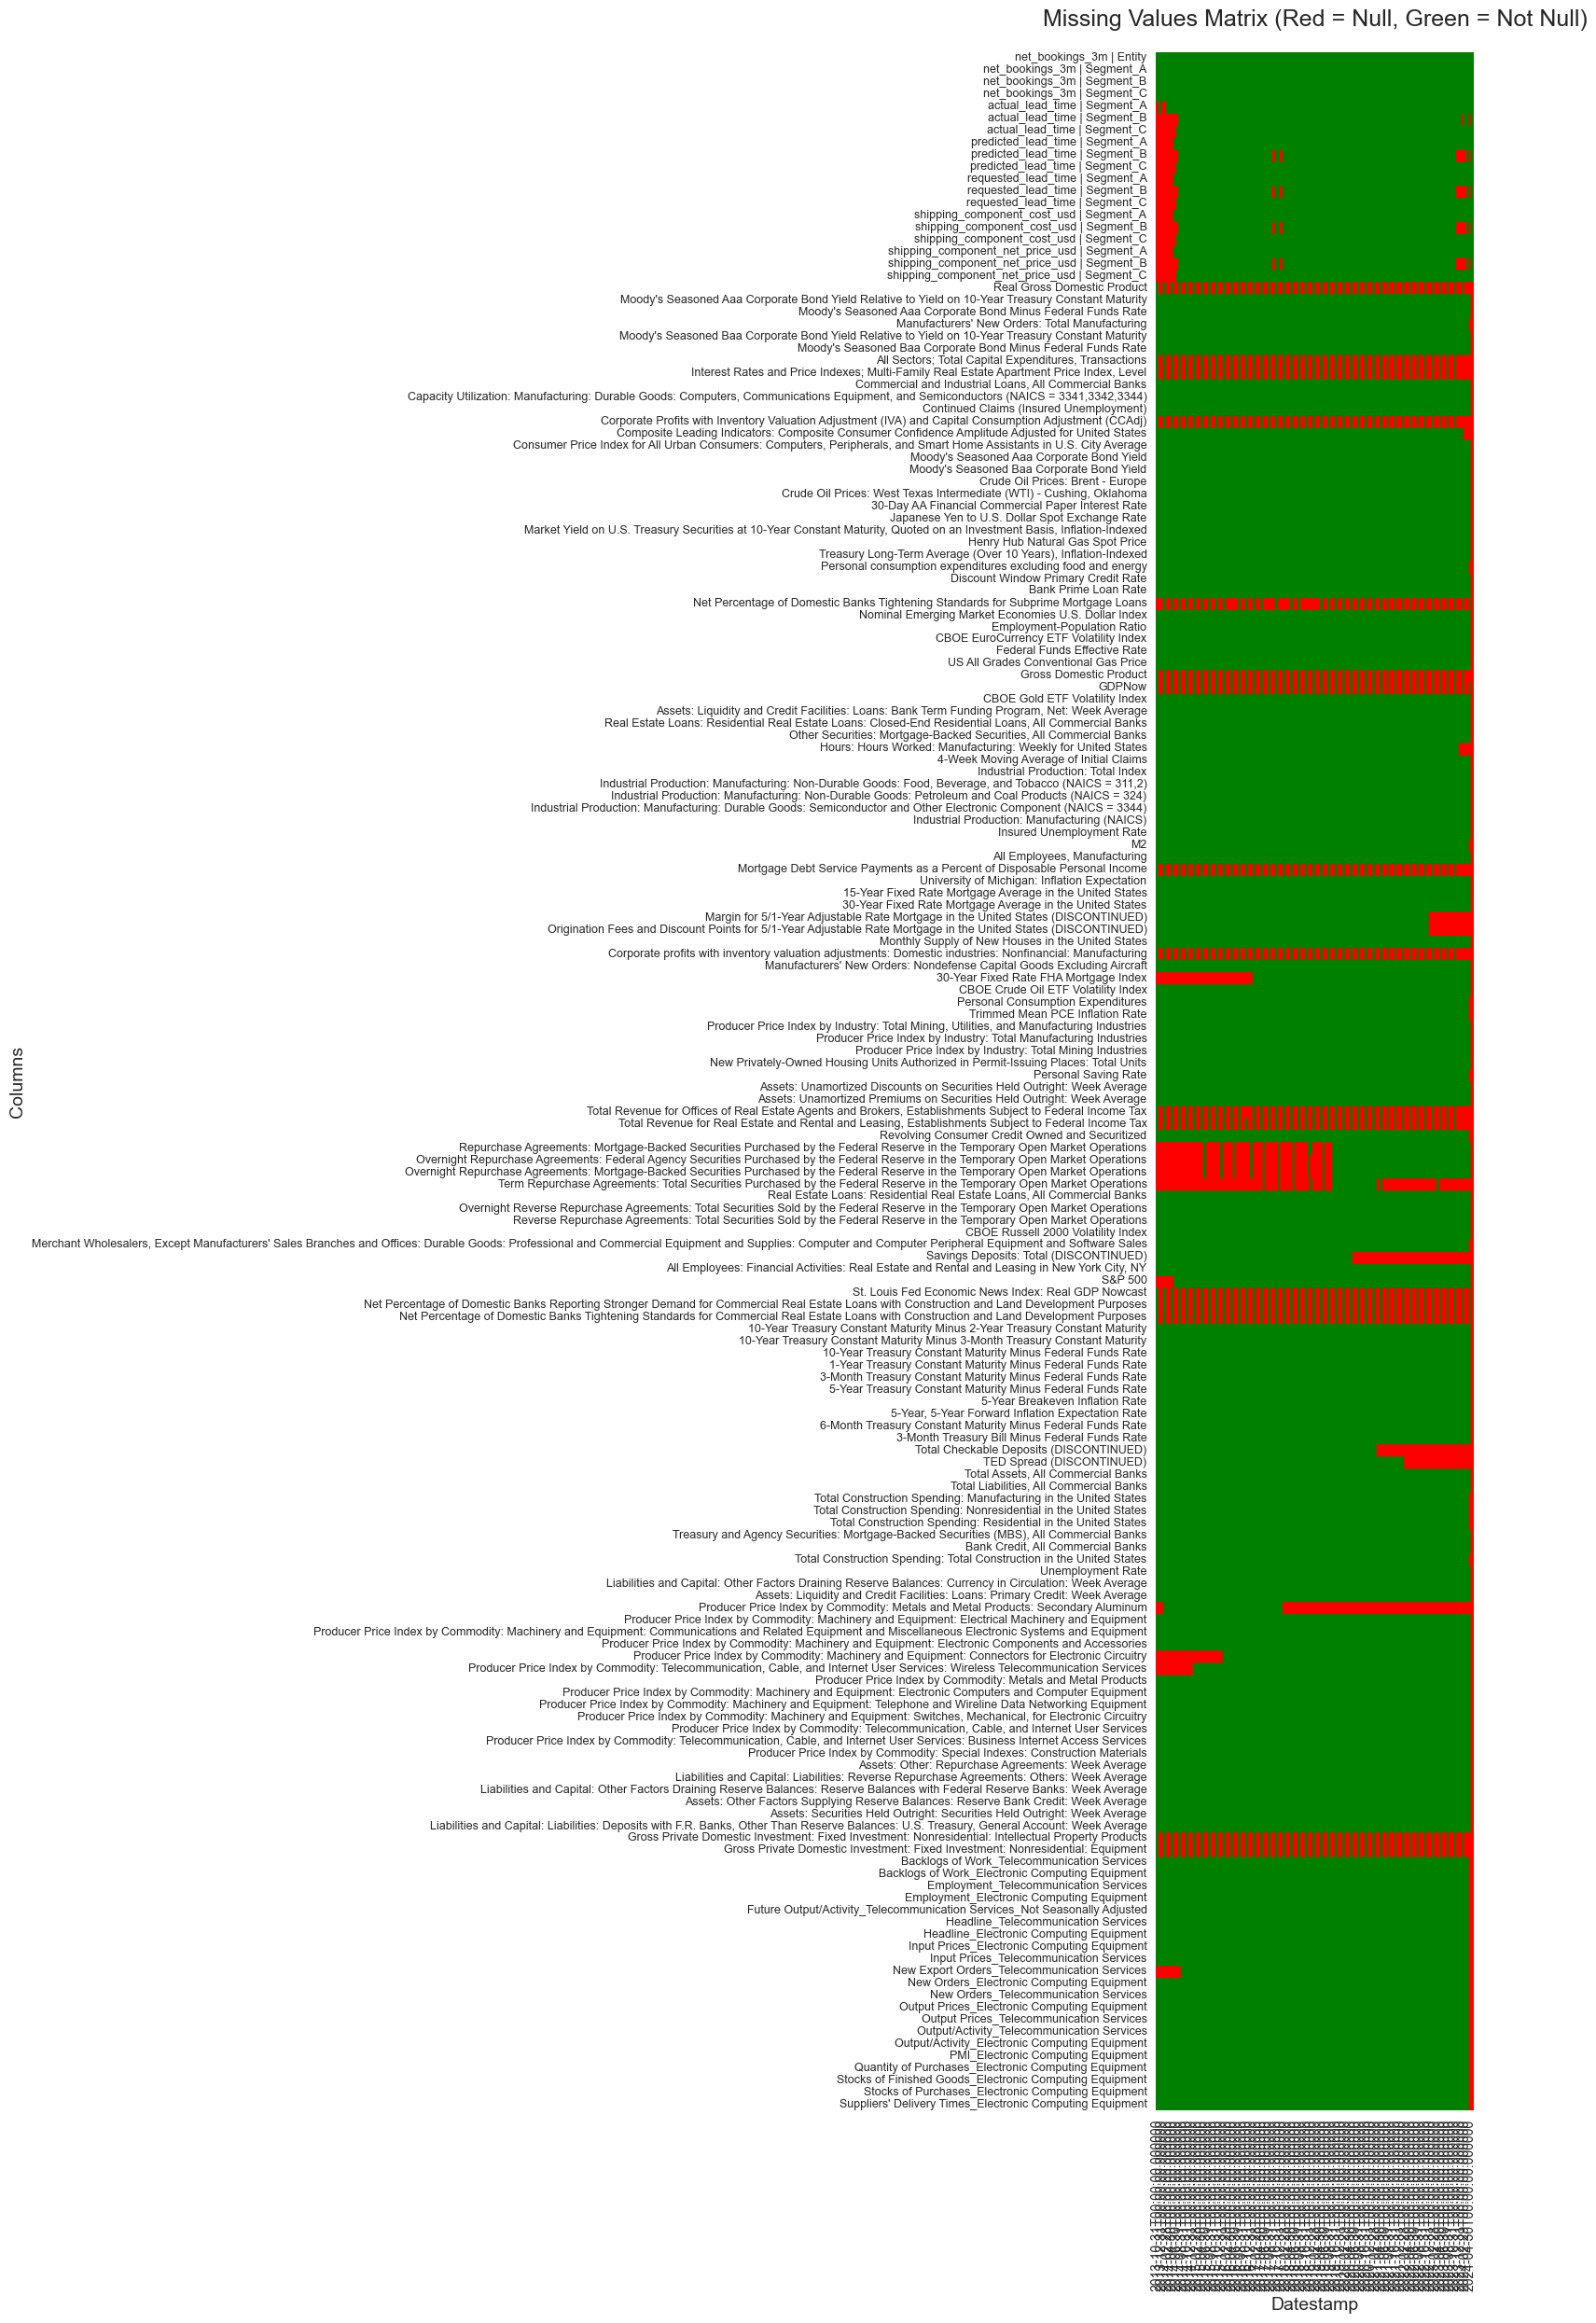

In [8]:
# Ensure the dataframe is sorted chronologically by the datestamp index
df_sorted = df.sort_index()

# Create a boolean matrix where True (1) is a null value, and False (0) is not null
# We transpose it (.T) so columns are on the y-axis and dates are on the x-axis
null_matrix = df_sorted.isnull().T

# Define a custom color map: False (0) = Green, True (1) = Red
cmap = ListedColormap(['green', 'red'])

# Initialize a large figure
plt.figure(figsize=(16, 25))

# Plot the heatmap
# cbar=False removes the color legend since we only have two explicit colors
ax = sns.heatmap(null_matrix, cmap=cmap, cbar=False, yticklabels=True)

# Add title and axis labels
plt.title('Missing Values Matrix (Red = Null, Green = Not Null)', fontsize=18, pad=20)
plt.xlabel('Datestamp', fontsize=14)
plt.ylabel('Columns', fontsize=14)

# Rotate y-axis labels so they are horizontal and easier to read
plt.yticks(rotation=0, fontsize=9)

# Adjust layout to prevent clipping of the long column names
plt.tight_layout()

# Display the matrix
plt.show()

### Addressing Nulls

In [ ]:
"""
LOW-VARIANCE FEATURE PRUNING LOGIC:
- Quantify the statistical variance across all numerical features to identify variables that offer minimal information gain for the model.
- Isolate near-constant columns by applying a variance threshold of 0.01, targeting features that lack sufficient volatility to act as predictive signals.
- Implement a threshold to ensure that business-critical segment labels and target variables are preserved, regardless of their individual variance levels.
"""

'\nLOW-VARIANCE FEATURE PRUNING LOGIC:\n- Quantify the statistical variance across all numerical features to identify variables that offer minimal information gain for the model.\n- Isolate near-constant columns by applying a variance threshold of 0.1, targeting features that lack sufficient volatility to act as predictive signals.\n- Implement a protection filter to ensure that business-critical segment labels and target variables are preserved, regardless of their individual variance levels.\n- Streamline the dataset by removing non-informative macroeconomic or internal drivers that could introduce noise or lead to model instability.\n- Log the successfully removed features to maintain a clear audit trail of the dimensionality reduction and data cleaning process.\n'

In [10]:
# Calculate the variance for all numerical columns
variances = df.var(numeric_only=True)

# Identify columns with variance less than 0.1
low_var_cols = variances[variances < 0.01].index.tolist()

# Exclude columns containing 'net_bookings_3m' from the drop list
cols_to_drop = [col for col in low_var_cols if 'Segment_' not in col]

# Drop the identified columns
df = df.drop(columns=cols_to_drop)

print('Dropped columns : ',cols_to_drop)

Dropped columns :  ['Margin for 5/1-Year Adjustable Rate Mortgage in the United States (DISCONTINUED)', 'Origination Fees and Discount Points for 5/1-Year Adjustable Rate Mortgage in the United States (DISCONTINUED)']


In [ ]:
"""
DATA PRE-PROCESSING & IMPUTATION LOGIC:
- Lead Time Consolidation: Consolidated actual, predicted, and requested lead times into a single prioritized "Source of Truth" column for each segment.
- Redundancy Cleanup: Droped the original redundant lead time source columns to streamline the feature set and reduce noise.
- Status Persistence: Forward-filled columns containing "discontinued" to ensure that once a product status changes, it is maintained through the rest of the timeline.
- Event Defaulting: Filled missing values in "temporary" event columns with zero, assuming the event did not occur unless explicitly recorded.
- Quarterly Signal Alignment: Heuristically identified quarterly macro-indicators by detecting ~90-day gaps and forward-filling them to create a continuous monthly "staircase" signal.
- Quality Threshold Filtering: Removed all features missing more than 20% of their historical data to prioritize high-quality, reliable inputs for the model.
- Gap Smoothing: Used linear interpolation and forward-extrapolation to bridge any remaining small data gaps and ensure values are present for the most recent period.
- Final Data Audit: Conducted a final null-value check to verify that the dataset is completely dense and ready for the feature selection and training phase.
"""

'\nDATA PRE-PROCESSING & IMPUTATION LOGIC:\n- Lead Time Consolidation: Consolidate actual, predicted, and requested lead times into a single prioritized "Source of Truth" column for each segment.\n- Redundancy Cleanup: Drop the original redundant lead time source columns to streamline the feature set and reduce noise.\n- Status Persistence: Forward-fill columns containing "discontinued" to ensure that once a product status changes, it is maintained through the rest of the timeline.\n- Event Defaulting: Fill missing values in "temporary" event columns with zero, assuming the event did not occur unless explicitly recorded.\n- Quarterly Signal Alignment: Heuristically identify quarterly macro-indicators by detecting ~90-day gaps and forward-filling them to create a continuous monthly "staircase" signal.\n- Quality Threshold Filtering: Remove all features missing more than 20% of their historical data to prioritize high-quality, reliable inputs for the model.\n- Gap Smoothing: Use linear i

In [11]:
# Create separate lead_time columns for Segment_A, Segment_B, Segment_C using coalesce(actual,predicted,requested)
seg_labels = ['A', 'B', 'C']
for seg in seg_labels:
    actual_col = f'actual_lead_time | Segment_{seg}'
    predicted_col = f'predicted_lead_time | Segment_{seg}'
    requested_col = f'requested_lead_time | Segment_{seg}'
    if all(col in df.columns for col in [actual_col, predicted_col, requested_col]):
        df[f'lead_time_Segment_{seg}'] = (
            df[[actual_col, predicted_col, requested_col]]
              .bfill(axis=1)
              .iloc[:, 0]
        )
        print(f'lead_time_Segment_{seg} created; non-null count:', df[f'lead_time_Segment_{seg}'].notna().sum())
    else:
        missing = [c for c in [actual_col, predicted_col, requested_col] if c not in df.columns]
        raise KeyError(f'missing columns for segment {seg}: {missing}')

# Drop existing actual/predicted/requested lead time columns
cols_to_drop = [
    'actual_lead_time | Segment_A', 'predicted_lead_time | Segment_A', 'requested_lead_time | Segment_A',
    'actual_lead_time | Segment_B', 'predicted_lead_time | Segment_B', 'requested_lead_time | Segment_B',
    'actual_lead_time | Segment_C', 'predicted_lead_time | Segment_C', 'requested_lead_time | Segment_C'
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 1. Identify columns that have 'discontinued' in their name (case-insensitive)
discontinued_cols = [col for col in df.columns if 'discontinued' in col.lower()]

# 2. Forward fill the missing values in these columns
# .ffill() takes the last known non-null value and propagates it forward
df[discontinued_cols] = df[discontinued_cols].ffill()

# 1. Identify columns that contain the word 'temporary' (case-insensitive)
temporary_cols = [col for col in df.columns if 'temporary' in col.lower()]

print(f"\nFound {len(temporary_cols)} columns containing 'temporary':")
for col in temporary_cols:
    print(f" - {col}")

# 2. Fill missing values (nulls) in these specific columns with 0
if temporary_cols:
    df[temporary_cols] = df[temporary_cols].fillna(0)
    print("\nSuccessfully filled missing values with 0 for the identified columns.")
else:
    print("\nNo columns found containing the word 'temporary'.")

# Identify "Quarterly" columns heuristically
quarterly_cols = []

for col in df.columns:
    # Get the timestamps where the column actually has data
    valid_dates = df[col].dropna().index
    
    if len(valid_dates) > 1:
        # Calculate the median number of days between reported values
        median_gap = valid_dates.to_series().diff().dt.days.median()
        
        # A quarter is roughly 90-92 days. We use a buffer of 85 to 95 days.
        if 85 <= median_gap <= 95:
            quarterly_cols.append(col)

print(f"\nIdentified {len(quarterly_cols)} columns with a quarterly reporting pattern.")

# 2. Apply forward-fill ONLY to these specific quarterly columns
if quarterly_cols:
    df[quarterly_cols] = df[quarterly_cols].ffill()
    print("Successfully applied forward-fill to the quarterly columns.")

# Calculate the percentage of nulls for each column
null_percentages = (df.isnull().sum() / len(df)) * 100

# Identify columns to keep (those with 50% or less nulls)
columns_to_keep = null_percentages[null_percentages <= 20].index

# Update the DataFrame to keep only those columns
df = df[columns_to_keep]

print(f"Number of columns remaining after dropping >50% nulls: {len(df.columns)}")

# 2. Use interpolation to predict any values missing at the end
# limit_direction='forward' ensures we extrapolate towards the end of the timeline
df = df.interpolate(method='linear', limit_direction='forward')

# 3. List all columns which still have null values
remaining_nulls = df.isnull().sum()
cols_with_nulls = remaining_nulls[remaining_nulls > 0]

print("-" * 50)
if len(cols_with_nulls) > 0:
    print(f"There are {len(cols_with_nulls)} columns that still have null values:\n")
    for col, count in cols_with_nulls.items():
        print(f" - {col}: {count} nulls remaining")
else:
    print("Success! There are exactly 0 columns with null values remaining.")
print("-" * 50)

lead_time_Segment_A created; non-null count: 125
lead_time_Segment_B created; non-null count: 117
lead_time_Segment_C created; non-null count: 120

Found 6 columns containing 'temporary':
 - Repurchase Agreements: Mortgage-Backed Securities Purchased by the Federal Reserve in the Temporary Open Market Operations
 - Overnight Repurchase Agreements: Federal Agency Securities Purchased by the Federal Reserve in the Temporary Open Market Operations
 - Overnight Repurchase Agreements: Mortgage-Backed Securities Purchased by the Federal Reserve in the Temporary Open Market Operations
 - Term Repurchase Agreements: Total Securities Purchased by the Federal Reserve in the Temporary Open Market Operations
 - Overnight Reverse Repurchase Agreements: Total Securities Sold by the Federal Reserve in the Temporary Open Market Operations
 - Reverse Repurchase Agreements: Total Securities Sold by the Federal Reserve in the Temporary Open Market Operations

Successfully filled missing values with 0 for

In [ ]:
"""
MISSING VALUES VISUALIZATION LOGIC:
- Chronologically sort the dataset by the date index to ensure that missing value patterns are viewed sequentially over time.
- Generate a boolean matrix of null values and transpose it so that features appear on the y-axis and time on the x-axis.
- Create a heatmap visualization to pinpoint exactly when and where data gaps occur within the macroeconomic and internal feature sets.
- Apply descriptive titles and horizontal axis labels to ensure that specific features and time periods are easily identifiable.
"""

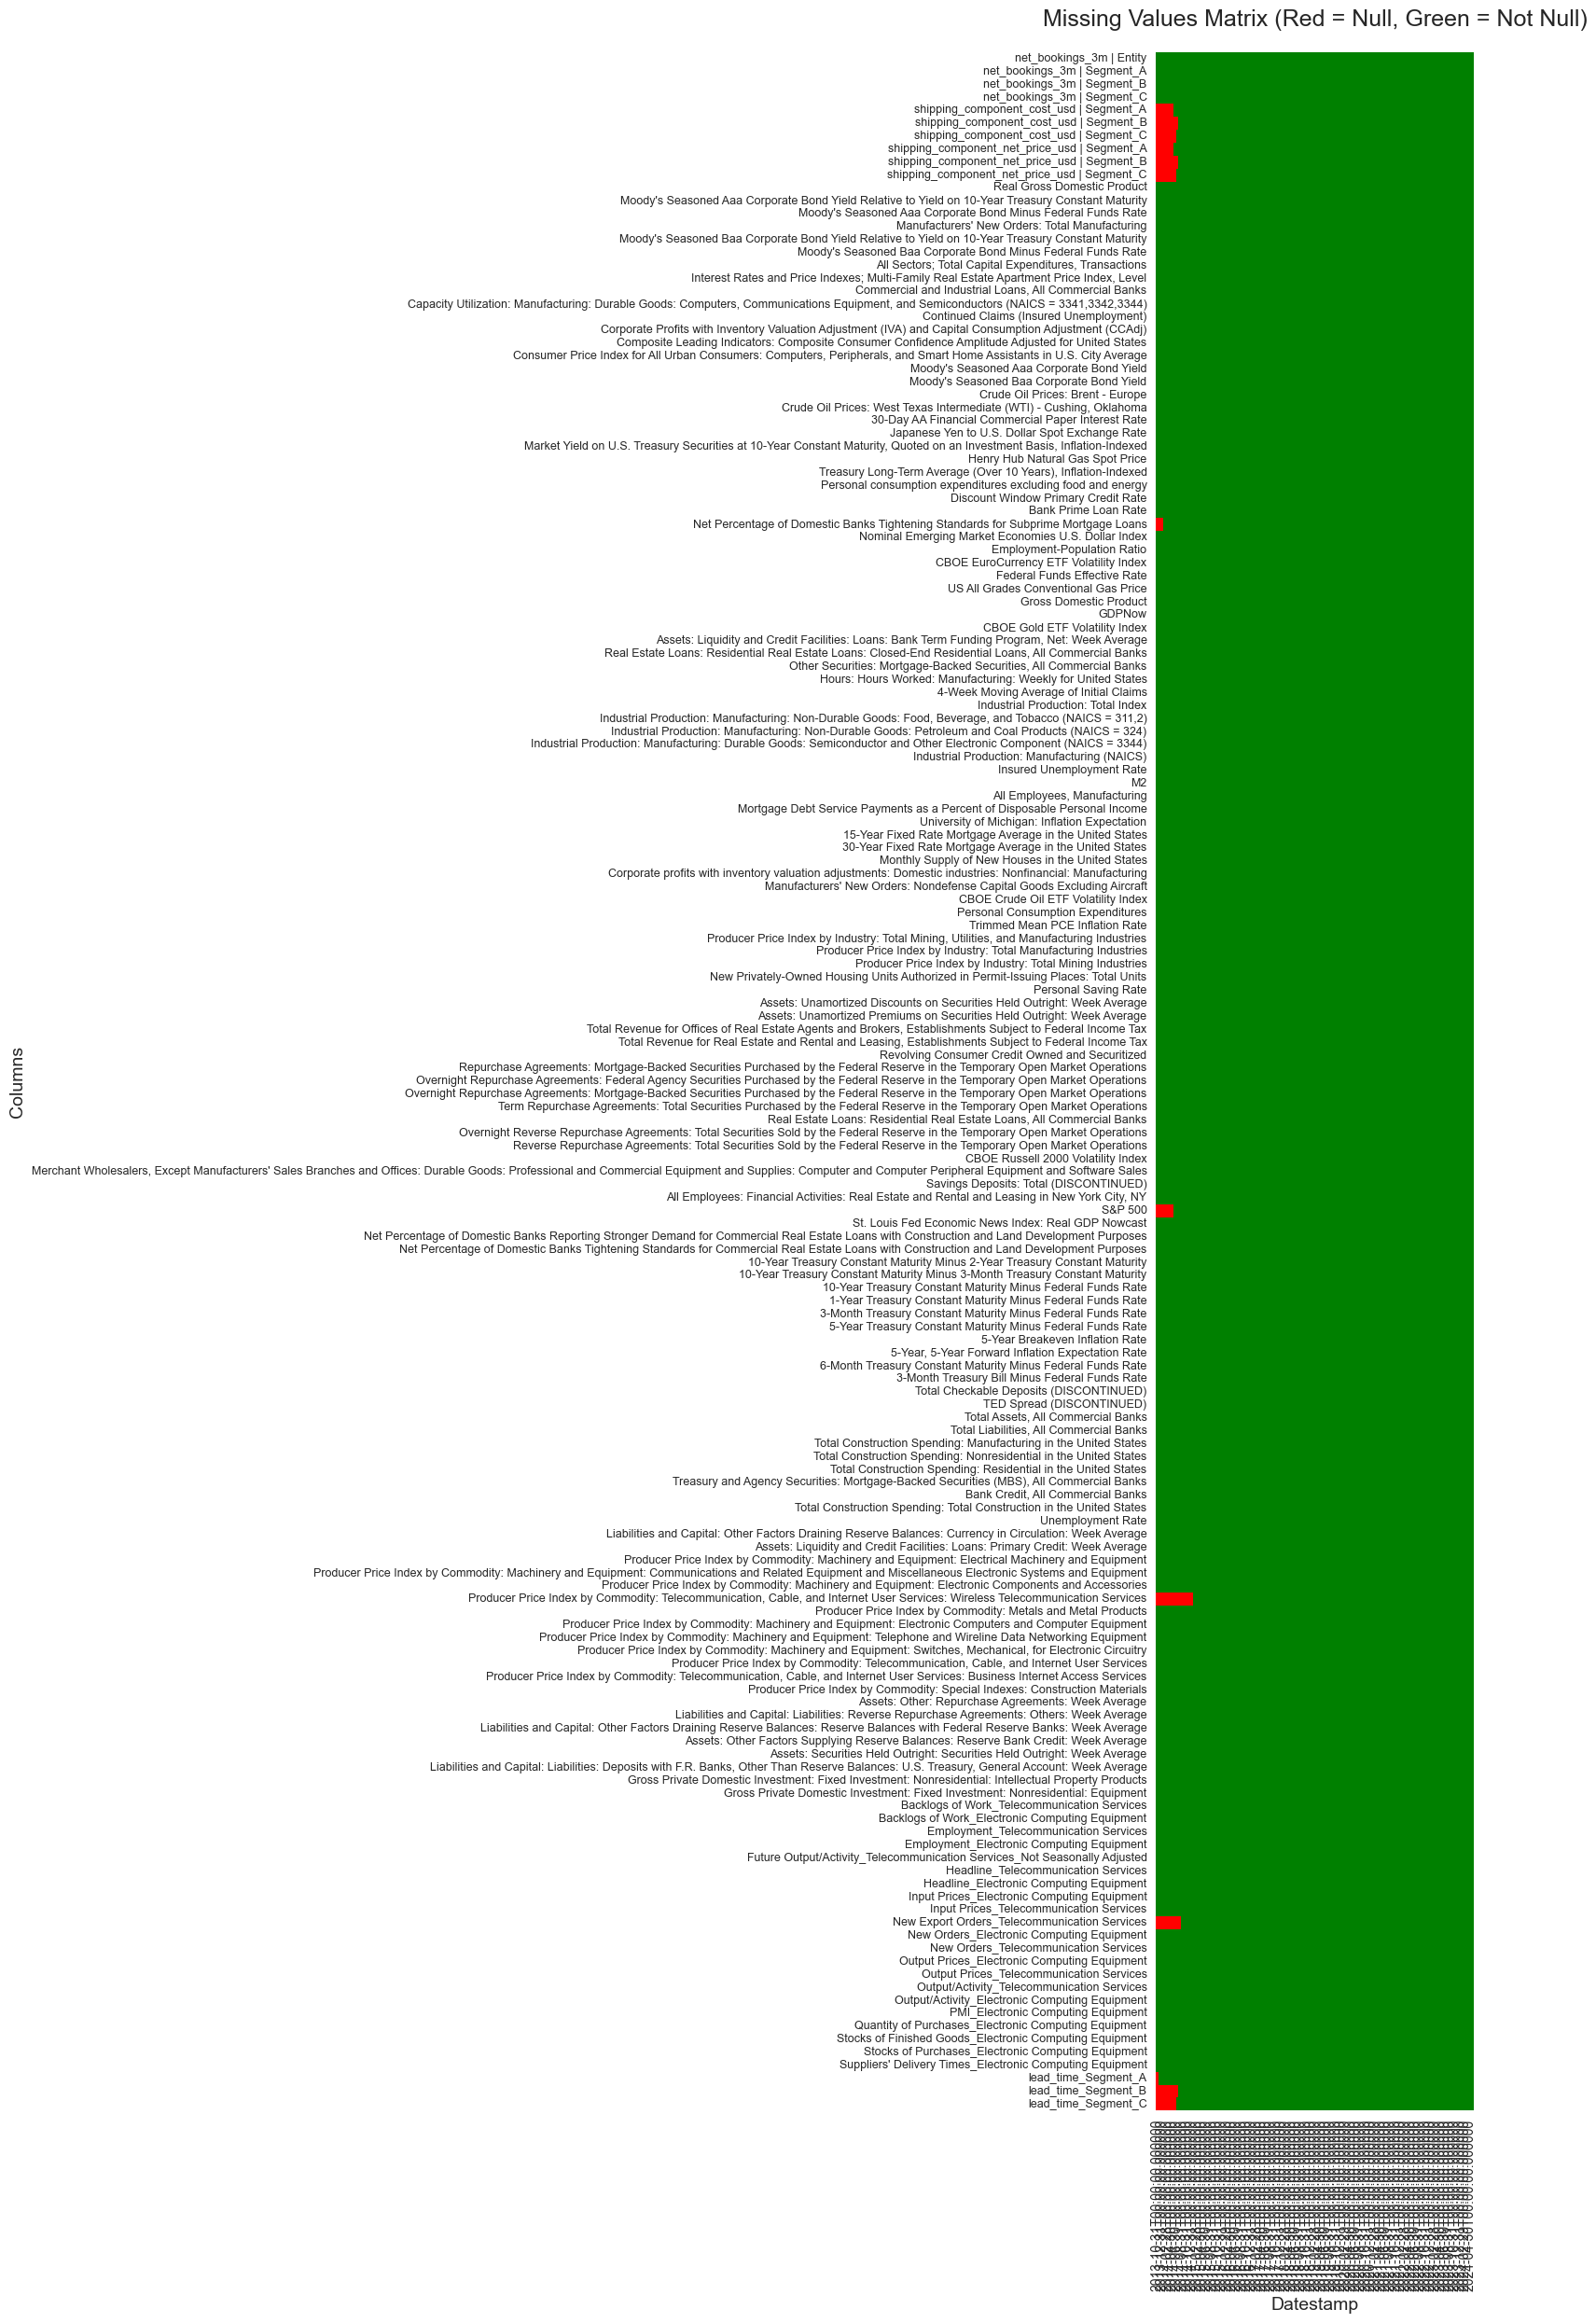

In [12]:
# Ensure the dataframe is sorted chronologically by the datestamp index
df_sorted = df.sort_index()

# Create a boolean matrix where True (1) is a null value, and False (0) is not null
# We transpose it (.T) so columns are on the y-axis and dates are on the x-axis
null_matrix = df_sorted.isnull().T

# Define a custom color map: False (0) = Green, True (1) = Red
cmap = ListedColormap(['green', 'red'])

# Initialize a large figure
plt.figure(figsize=(16, 25))

# Plot the heatmap
# cbar=False removes the color legend since we only have two explicit colors
ax = sns.heatmap(null_matrix, cmap=cmap, cbar=False, yticklabels=True)

# Add title and axis labels
plt.title('Missing Values Matrix (Red = Null, Green = Not Null)', fontsize=18, pad=20)
plt.xlabel('Datestamp', fontsize=14)
plt.ylabel('Columns', fontsize=14)

# Rotate y-axis labels so they are horizontal and easier to read
plt.yticks(rotation=0, fontsize=9)

# Adjust layout to prevent clipping of the long column names
plt.tight_layout()

# Display the matrix
plt.show()

In [ ]:
"""
SEGMENT-SPECIFIC DATA SUBDIVISION LOGIC:
- Isolate shared macroeconomic indicators by filtering out any columns that contain segment-specific labels or global entity targets.
- Categorize the remaining features into segment-specific groups by identifying unique labels for Segment A, B, and C within the column names.
- Construct independent DataFrames for each business segment by merging the universal macroeconomic features with their respective segment-specific data.
"""

In [13]:
# 1. Identify all macroeconomic (general) columns 
# We exclude any columns that mention a segment or the 'net_bookings_3m | Entity' target
exclude_strings = ['Segment_A', 'Segment_B', 'Segment_C', 'net_bookings_3m | Entity']
macro_cols = [c for c in df.columns if not any(s in c for s in exclude_strings)]

# 2. Identify segment-specific columns for each segment
seg_A_cols = [c for c in df.columns if 'Segment_A' in c]
seg_B_cols = [c for c in df.columns if 'Segment_B' in c]
seg_C_cols = [c for c in df.columns if 'Segment_C' in c]

# 3. Create the subdivided dataframes
# Each dataframe contains the macro columns + its own specific columns
df_A = df[macro_cols + seg_A_cols].copy()
df_B = df[macro_cols + seg_B_cols].copy()
df_C = df[macro_cols + seg_C_cols].copy()

# Optional: Verification
print(f"Total Columns in original df: {len(df.columns)}")
print("-" * 30)
print(f"Segment A DataFrame: {df_A.shape[1]} columns")
print(f"Segment B DataFrame: {df_B.shape[1]} columns")
print(f"Segment C DataFrame: {df_C.shape[1]} columns")
print("\nMacroeconomic columns shared across segments:", len(macro_cols))

Total Columns in original df: 159
------------------------------
Segment A DataFrame: 150 columns
Segment B DataFrame: 150 columns
Segment C DataFrame: 150 columns

Macroeconomic columns shared across segments: 146


In [ ]:
"""
SEQUENTIAL TIME-SERIES SPLITTING LOGIC:
- Define a utility function to handle sequential data splitting, ensuring the temporal order of observations is preserved to prevent data leakage.
- Calculate a precise integer split index based on a 70% training ratio to partition the historical data into distinct phases.
- Slice the segment-specific DataFrames into chronological training and testing sets using position-based indexing instead of random shuffling.
- Execute the splitting logic across all three business segments to create independent environments for model training and out-of-sample evaluation.
- Validate the boundaries by checking the end of the training set against the start of the test set to ensure a clean transition with no overlap.
"""

In [14]:
# Define a helper function for sequential time-series splitting
def time_series_split(dataframe, train_ratio=0.7):
    """
    Splits a dataframe sequentially into train and test sets.
    Assumes the dataframe is already sorted by its datetime index.
    """
    # Calculate the integer index for the split
    split_index = int(len(dataframe) * train_ratio)
    
    # Split the data
    train_df = dataframe.iloc[:split_index].copy()
    test_df = dataframe.iloc[split_index:].copy()
    
    return train_df, test_df

# Apply the split to each segment
train_A, test_A = time_series_split(df_A, train_ratio=0.7)
train_B, test_B = time_series_split(df_B, train_ratio=0.7)
train_C, test_C = time_series_split(df_C, train_ratio=0.7)

# Verify the splits
print("--- Train/Test Split Verification ---")
print(f"Segment A | Train: {train_A.shape[0]} rows ({len(train_A)/len(df_A):.0%}) | Test: {test_A.shape[0]} rows ({len(test_A)/len(df_A):.0%})")
print(f"Segment B | Train: {train_B.shape[0]} rows ({len(train_B)/len(df_B):.0%}) | Test: {test_B.shape[0]} rows ({len(test_B)/len(df_B):.0%})")
print(f"Segment C | Train: {train_C.shape[0]} rows ({len(train_C)/len(df_C):.0%}) | Test: {test_C.shape[0]} rows ({len(test_C)/len(df_C):.0%})")

# Optional: Check the boundary dates to ensure no overlap
print("\n--- Split Boundaries ---")
print(f"Segment A Train Ends: {train_A.index.max().date()} | Test Begins: {test_A.index.min().date()}")

--- Train/Test Split Verification ---
Segment A | Train: 89 rows (70%) | Test: 39 rows (30%)
Segment B | Train: 89 rows (70%) | Test: 39 rows (30%)
Segment C | Train: 89 rows (70%) | Test: 39 rows (30%)

--- Split Boundaries ---
Segment A Train Ends: 2021-02-28 | Test Begins: 2021-03-31


In [ ]:
"""
LAGGED FEATURE ENGINEERING AND CORRELATION FILTERING LOGIC:
- Generate historical "lagged" versions of every feature to provide the model with a multi-month temporal context for each observation.
- Partition the augmented datasets into training and testing sets sequentially to ensure the chronological order of the time-series data.
- Calculate a correlation matrix exclusively on the training data to identify redundant features while strictly preventing information leakage from the future.
- Protect the target booking variables from the filtering process to ensure the model's primary prediction objective is never accidentally removed.
- Identify and drop highly correlated features using the upper triangle of the correlation matrix to reduce multicollinearity and improve model stability.
- Execute the full engineering and filtering pipeline across all business segments to produce optimized datasets ready for model training.
"""

In [15]:
# 1. Define the lag creation function
def create_lagged_features(df, n_lags=3):
    lagged_data = [df]
    for lag in range(1, n_lags + 1):
        shifted = df.shift(lag)
        shifted.columns = [f"{col}_lag{lag}" for col in df.columns]
        lagged_data.append(shifted)
    return pd.concat(lagged_data, axis=1)

# 2. Define the split function
def time_series_split(dataframe, train_ratio=0.7):
    split_index = int(len(dataframe) * train_ratio)
    train_df = dataframe.iloc[:split_index].copy()
    test_df = dataframe.iloc[split_index:].copy()
    return train_df, test_df

# 3. Define the correlation filter function
def drop_highly_correlated(train_df, test_df, threshold=0.8):
    """
    Drops features with a correlation strictly greater than the threshold.
    Calculates correlation ONLY on the training set to prevent data leakage.
    Protects target variables from being dropped.
    """
    # Identify target columns to protect them from being dropped
    target_cols = [c for c in train_df.columns if 'net_bookings_3m' in c]
    
    # Calculate the absolute correlation matrix
    corr_matrix = train_df.corr().abs()
    
    # Select the upper triangle of the correlation matrix 
    # (so we don't drop both features in a correlated pair)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold) and column not in target_cols]
    
    # Drop the features from both train and test sets
    train_reduced = train_df.drop(columns=to_drop)
    test_reduced = test_df.drop(columns=to_drop)
    
    return train_reduced, test_reduced, to_drop

# Apply the pipeline to Segment A
df_A_lagged = create_lagged_features(df_A, n_lags=3)
train_A, test_A = time_series_split(df_A_lagged, train_ratio=0.7)
train_A_filtered, test_A_filtered, dropped_A = drop_highly_correlated(train_A, test_A, threshold=0.8)

# Apply the pipeline to Segment B
df_B_lagged = create_lagged_features(df_B, n_lags=3)
train_B, test_B = time_series_split(df_B_lagged, train_ratio=0.7)
train_B_filtered, test_B_filtered, dropped_B = drop_highly_correlated(train_B, test_B, threshold=0.8)


# Apply the pipeline to Segment A
df_C_lagged = create_lagged_features(df_C, n_lags=3)
train_C, test_C = time_series_split(df_C_lagged, train_ratio=0.7)
train_C_filtered, test_C_filtered, dropped_C = drop_highly_correlated(train_C, test_C, threshold=0.8)

In [ ]:
"""
FEATURE IMPORTANCE ANALYSIS AND VISUALIZATION LOGIC:
- Map segmented DataFrames into a centralized dictionary.
- Perform a direct comparison of the top predictive drivers for each segment.
- Calculate a "differenced" target variable to focus the model on predicting the period-over-period change rather than absolute booking values.
- Implement strict data leakage prevention by identifying and removing all contemporaneous target variables from the training feature set.
- Apply mean imputation to resolve any remaining null values, ensuring a mathematically complete matrix for the regressor.
- Train a Gradient Boosting Regressor to determine feature importance based on the relative reduction in impurity (Mean Squared Error).
- Extract and rank the top five most influential features per segment to isolate the primary macroeconomic and internal drivers of demand.
- Generate horizontal bar charts with precise labels to provide a clear, quantitative view of each feature's predictive power.
"""

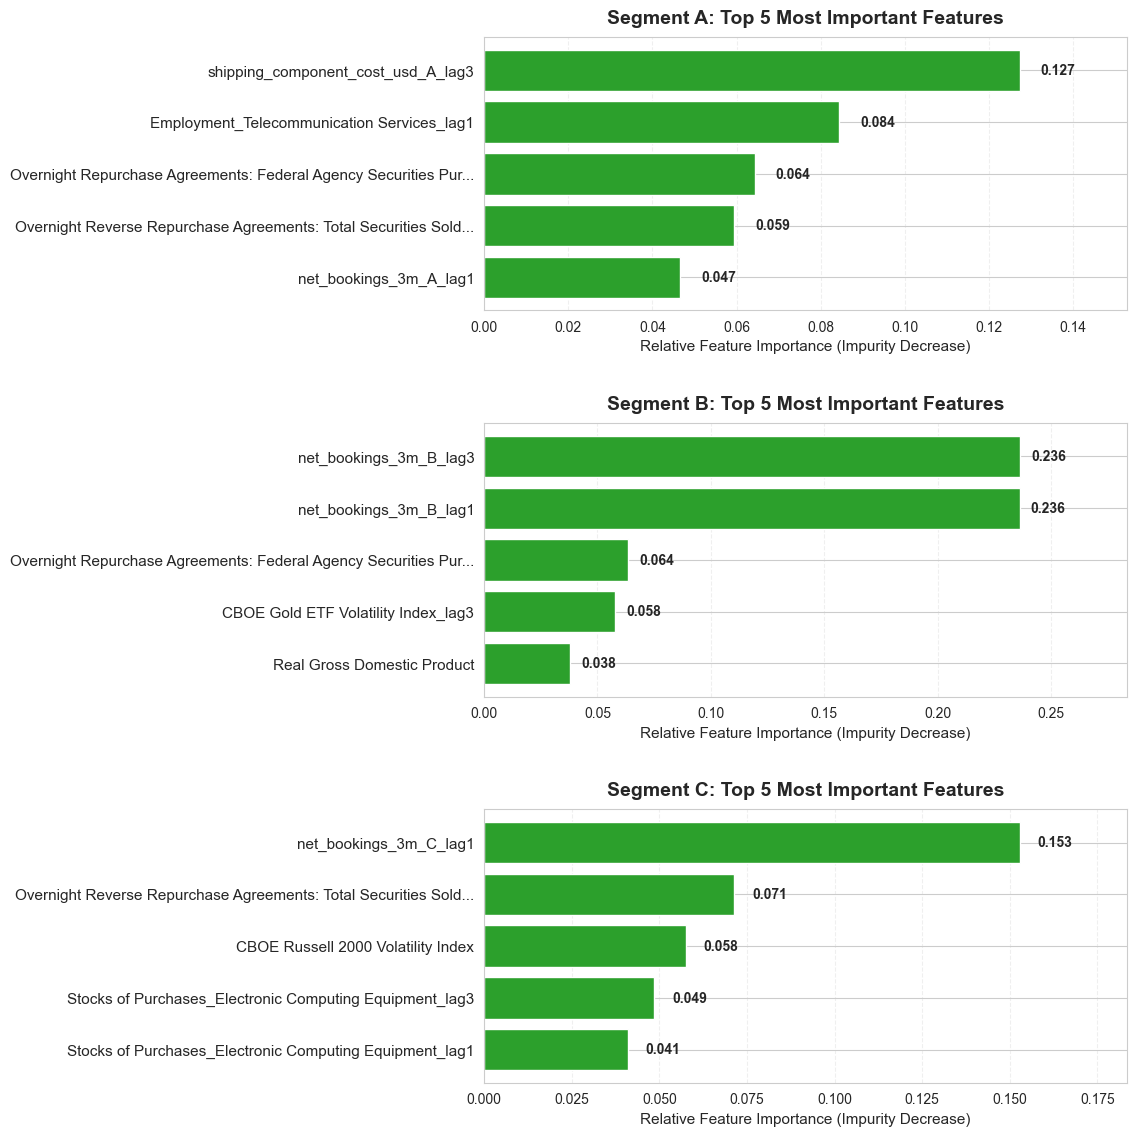

In [16]:
# Mapping the segments to their respective in-memory dataframes
datasets = {
    'A': (train_A_filtered, test_A_filtered),
    'B': (train_B_filtered, test_B_filtered),
    'C': (train_C_filtered, test_C_filtered)
}

# Create a 3x1 grid for horizontal bar charts
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for row_idx, (seg, (train_df, test_df)) in enumerate(datasets.items()):
    train = train_df.copy()
    test = test_df.copy()
    
    target_col = f'net_bookings_3m | Segment_{seg}'
    lag1_col = f'{target_col}_lag1'
    
    # Identify 't' columns to prevent data leakage
    t_targets = [c for c in train.columns if 'net_bookings_3m' in c and '_lag' not in c]
    
    X_train = train.drop(columns=t_targets)
    y_train_abs = train[target_col]
    train_lag1 = train[lag1_col]
    
    # Calculate differenced target (predicting the change)
    y_train_diff = y_train_abs - train_lag1
    
    # Mask to remove nulls
    train_mask = y_train_diff.notna() & y_train_abs.notna()
    X_train_clean = X_train[train_mask]
    y_train_diff_clean = y_train_diff[train_mask]
    
    # Feature selection logic matching our successful model
    imputer = SimpleImputer(strategy='mean')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)
    
    sel_model = GradientBoostingRegressor(random_state=42, max_depth=3)
    sel_model.fit(X_train_imp, y_train_diff_clean)
    
    # Extract feature importances
    importance_df = pd.DataFrame({'Feature': X_train_clean.columns, 'Imp': sel_model.feature_importances_})
    
    # Sort and get top 5
    top_5_features = importance_df.sort_values('Imp', ascending=False).head(5)
    
    # Clean feature names for plotting
    cleaned_features = [f.replace(' | Segment', '').replace(' (DISCONTINUED)', '') for f in top_5_features['Feature']]
    cleaned_features = [f if len(f) <= 65 else f[:62] + '...' for f in cleaned_features]
    
    # Reverse the order so the highest value sits at the top of the horizontal bar plot
    names = cleaned_features[::-1]
    values = top_5_features['Imp'].values[::-1]
    
    ax = axes[row_idx]
    
    # Create horizontal bar plot (using a distinct green color)
    bars = ax.barh(names, values, color='#2ca02c')
    
    # Add exact numerical values at the end of the bars
    for bar in bars:
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{bar.get_width():.3f}', 
                va='center', ha='left', fontsize=10, fontweight='bold')
    
    # Formatting the plot
    ax.set_title(f'Segment {seg}: Top 5 Most Important Features', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Relative Feature Importance (Impurity Decrease)', fontsize=11)
    
    # Adjust axes limits to make room for text labels
    ax.set_xlim(0, max(values) * 1.2)
    
    # Grid lines and ticks
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
"""
EXTERNAL DRIVER CORRELATION AND TIMELINE VISUALIZATION LOGIC:
- Compare the top three external predictive drivers against the target variable for each business segment.
- Calculate a differenced target variable to focus the Gradient Boosting model on predicting period-over-period changes in demand rather than absolute values.
- Implement strict leakage prevention by dropping all contemporaneous target columns from the feature matrix before model training.
- Rank features by their relative importance in explaining target variance, while specifically filtering out internal booking lags to isolate external drivers.
- Recombine training and testing datasets to visualize the full historical relationship between external features and bookings over the entire timeline.
- Utilize dual y-axes to overlay feature values against net bookings, enabling a direct visual comparison of trends across different data scales.
"""



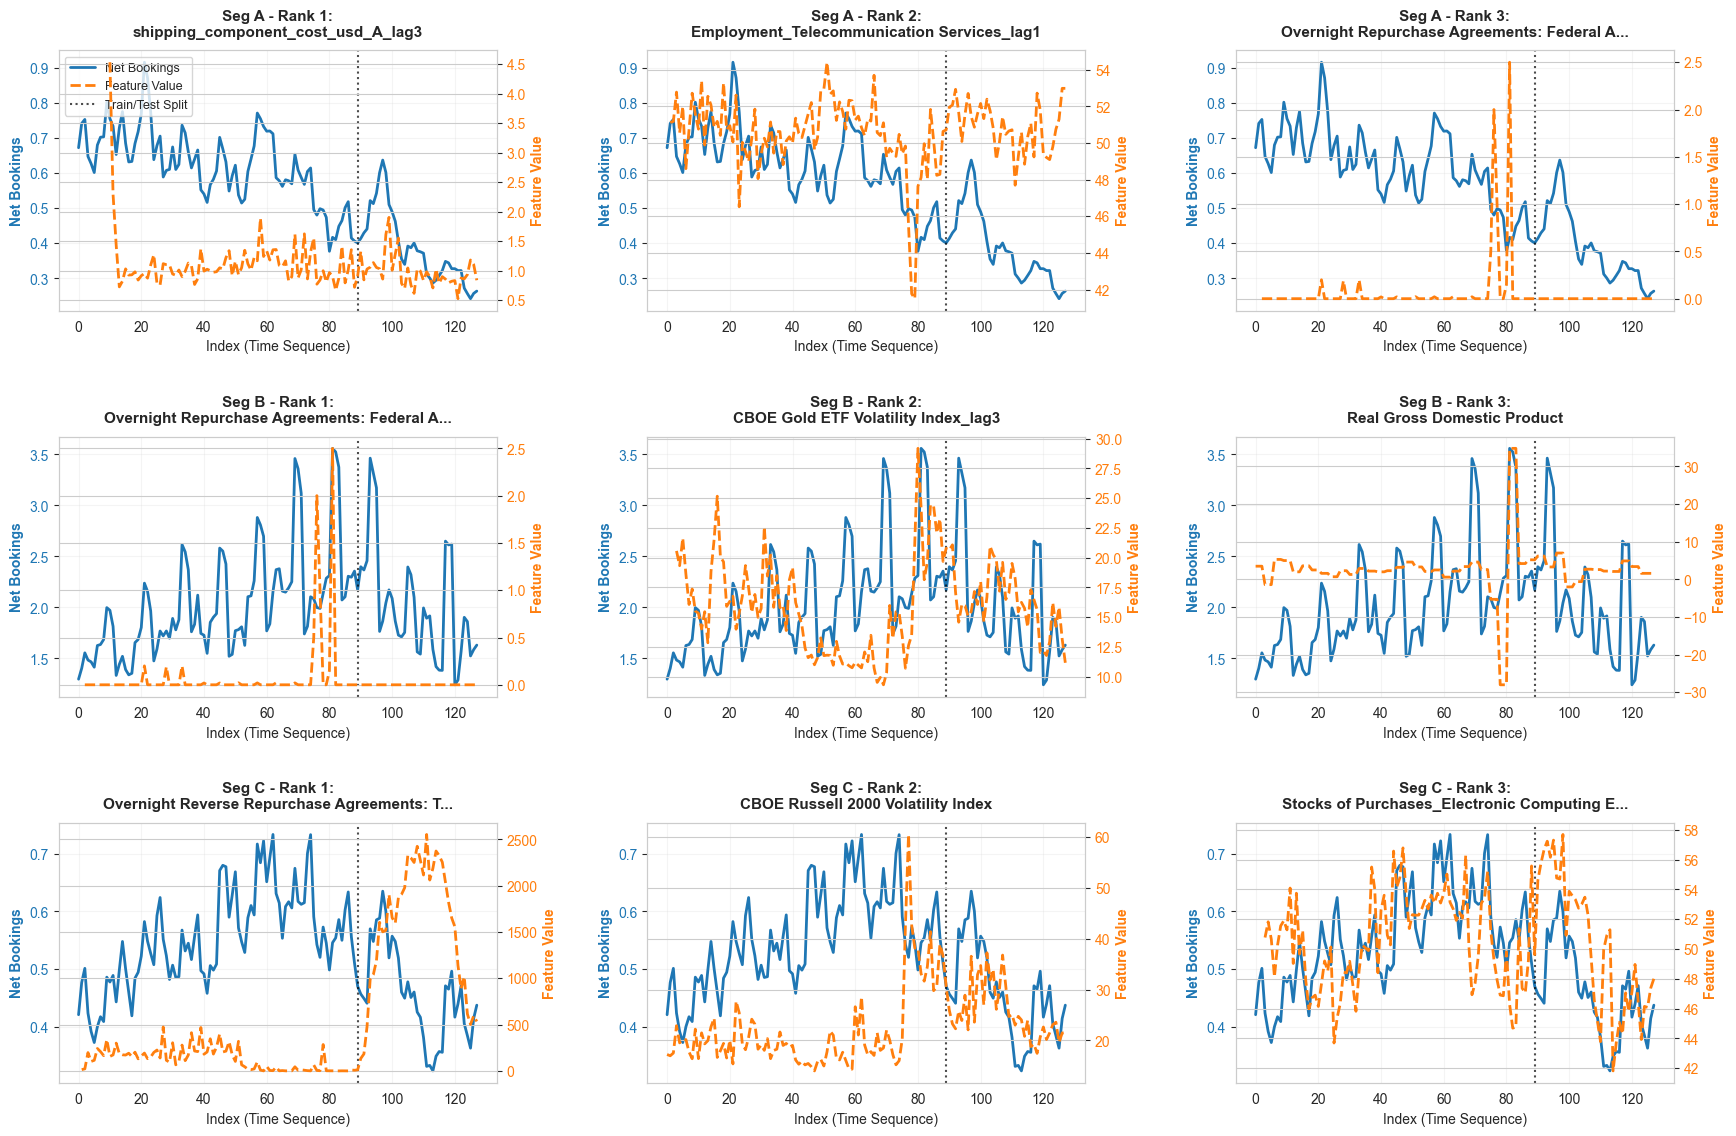

In [17]:
# Mapping the segments to their respective in-memory dataframes
datasets = {
    'A': (train_A_filtered, test_A_filtered),
    'B': (train_B_filtered, test_B_filtered),
    'C': (train_C_filtered, test_C_filtered)
}

# Create a 3x3 grid for subplots (3 segments x 3 top features)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (seg, (train_df, test_df)) in enumerate(datasets.items()):
    # Make a copy to avoid modifying the original dataframes in memory
    train = train_df.copy()
    test = test_df.copy()
    
    target_col = f'net_bookings_3m | Segment_{seg}'
    lag1_col = f'{target_col}_lag1'
    
    # Identify 't' columns to prevent data leakage
    t_targets = [c for c in train.columns if 'net_bookings_3m' in c and '_lag' not in c]
    
    X_train = train.drop(columns=t_targets)
    y_train_abs = train[target_col]
    train_lag1 = train[lag1_col]
    
    # Calculate differenced target (predicting the change)
    y_train_diff = y_train_abs - train_lag1
    
    # Mask to remove nulls
    train_mask = y_train_diff.notna() & y_train_abs.notna()
    X_train_clean = X_train[train_mask]
    y_train_diff_clean = y_train_diff[train_mask]
    
    # Feature selection logic matching our successful model
    imputer = SimpleImputer(strategy='mean')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)
    
    sel_model = GradientBoostingRegressor(random_state=42, max_depth=3)
    sel_model.fit(X_train_imp, y_train_diff_clean)
    
    # Extract feature importances
    importance_df = pd.DataFrame({'Feature': X_train_clean.columns, 'Imp': sel_model.feature_importances_})
    
    # EXCLUDE the target variable lags (anything containing 'net_bookings_3m')
    importance_df_filtered = importance_df[~importance_df['Feature'].str.contains('net_bookings_3m')]
    
    # Get top 3 external features
    top_3_features = importance_df_filtered.sort_values('Imp', ascending=False).head(3)['Feature'].tolist()
    
    # Combine train and test to plot the full historical timeline
    full_df = pd.concat([train, test], axis=0).reset_index(drop=True)
    time_index = full_df.index
    y_full_abs = full_df[target_col]
    split_idx = len(train)
    
    for col_idx, feat in enumerate(top_3_features):
        ax = axes[row_idx, col_idx]
        feat_full = full_df[feat]
        
        # Primary Y-axis: Target Variable (Solid Blue)
        color1 = '#1f77b4'
        l1, = ax.plot(time_index, y_full_abs, color=color1, linewidth=2, label='Net Bookings')
        ax.set_ylabel('Net Bookings', color=color1, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color1)
        
        # Secondary Y-axis: Feature (Dashed Orange)
        ax2 = ax.twinx()
        color2 = '#ff7f0e'
        l2, = ax2.plot(time_index, feat_full, color=color2, linewidth=2, linestyle='--', label='Feature Value')
        ax2.set_ylabel('Feature Value', color=color2, fontsize=10, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=color2)
        
        # Train/Test Split Boundary
        l3 = ax.axvline(x=split_idx, color='black', linestyle=':', alpha=0.7, label='Train/Test Split')
        
        # Format Titles & Legend
        # Truncate feature name to make the title cleaner visually
        title_feat = feat.replace(' | Segment', '').replace(' (DISCONTINUED)', '')
        if len(title_feat) > 45:
            title_feat = title_feat[:42] + '...'
            
        ax.set_title(f'Seg {seg} - Rank {col_idx+1}:\n{title_feat}', fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('Index (Time Sequence)')
        ax.grid(True, alpha=0.2)
        
        # Only add the legend to the first plot to avoid clutter
        if col_idx == 0 and row_idx == 0:
            ax.legend([l1, l2, l3], ['Net Bookings', 'Feature Value', 'Train/Test Split'], loc='upper left', fontsize=9)

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
"""
DIFFERENCED TIME-SERIES MODELING AND EVALUATION LOGIC:
- Map segment-specific datasets into a centralized dictionary to enable a standardized, iterative modeling pipeline across all business units.
- Implement strict leakage prevention by isolating the target booking variables and removing contemporaneous features from the training set.
- Apply first-order differencing to the target variables to shift the model's focus from absolute values to capturing period-over-period changes and trends.
- Clean the training and testing matrices by removing null values generated during the differencing and lagging processes to ensure mathematical stability.
- Execute a preliminary feature selection pass using Gradient Boosting to identify the top 10 most predictive drivers for each specific segment.
- Train a Gradient Boosting Regressor with L2 regularization to predict the differenced demand while minimizing the risk of overfitting.
- Reconstruct the final absolute booking forecasts by adding the predicted change back to the known baseline of the previous period.
- Calculate comprehensive performance metrics, including R², RMSE, and MAPE, to objectively evaluate model accuracy across both training and testing phases.
- Generate comparative time-series visualizations that overlay actual versus predicted bookings, providing a clear audit of the model's predictive performance.
"""

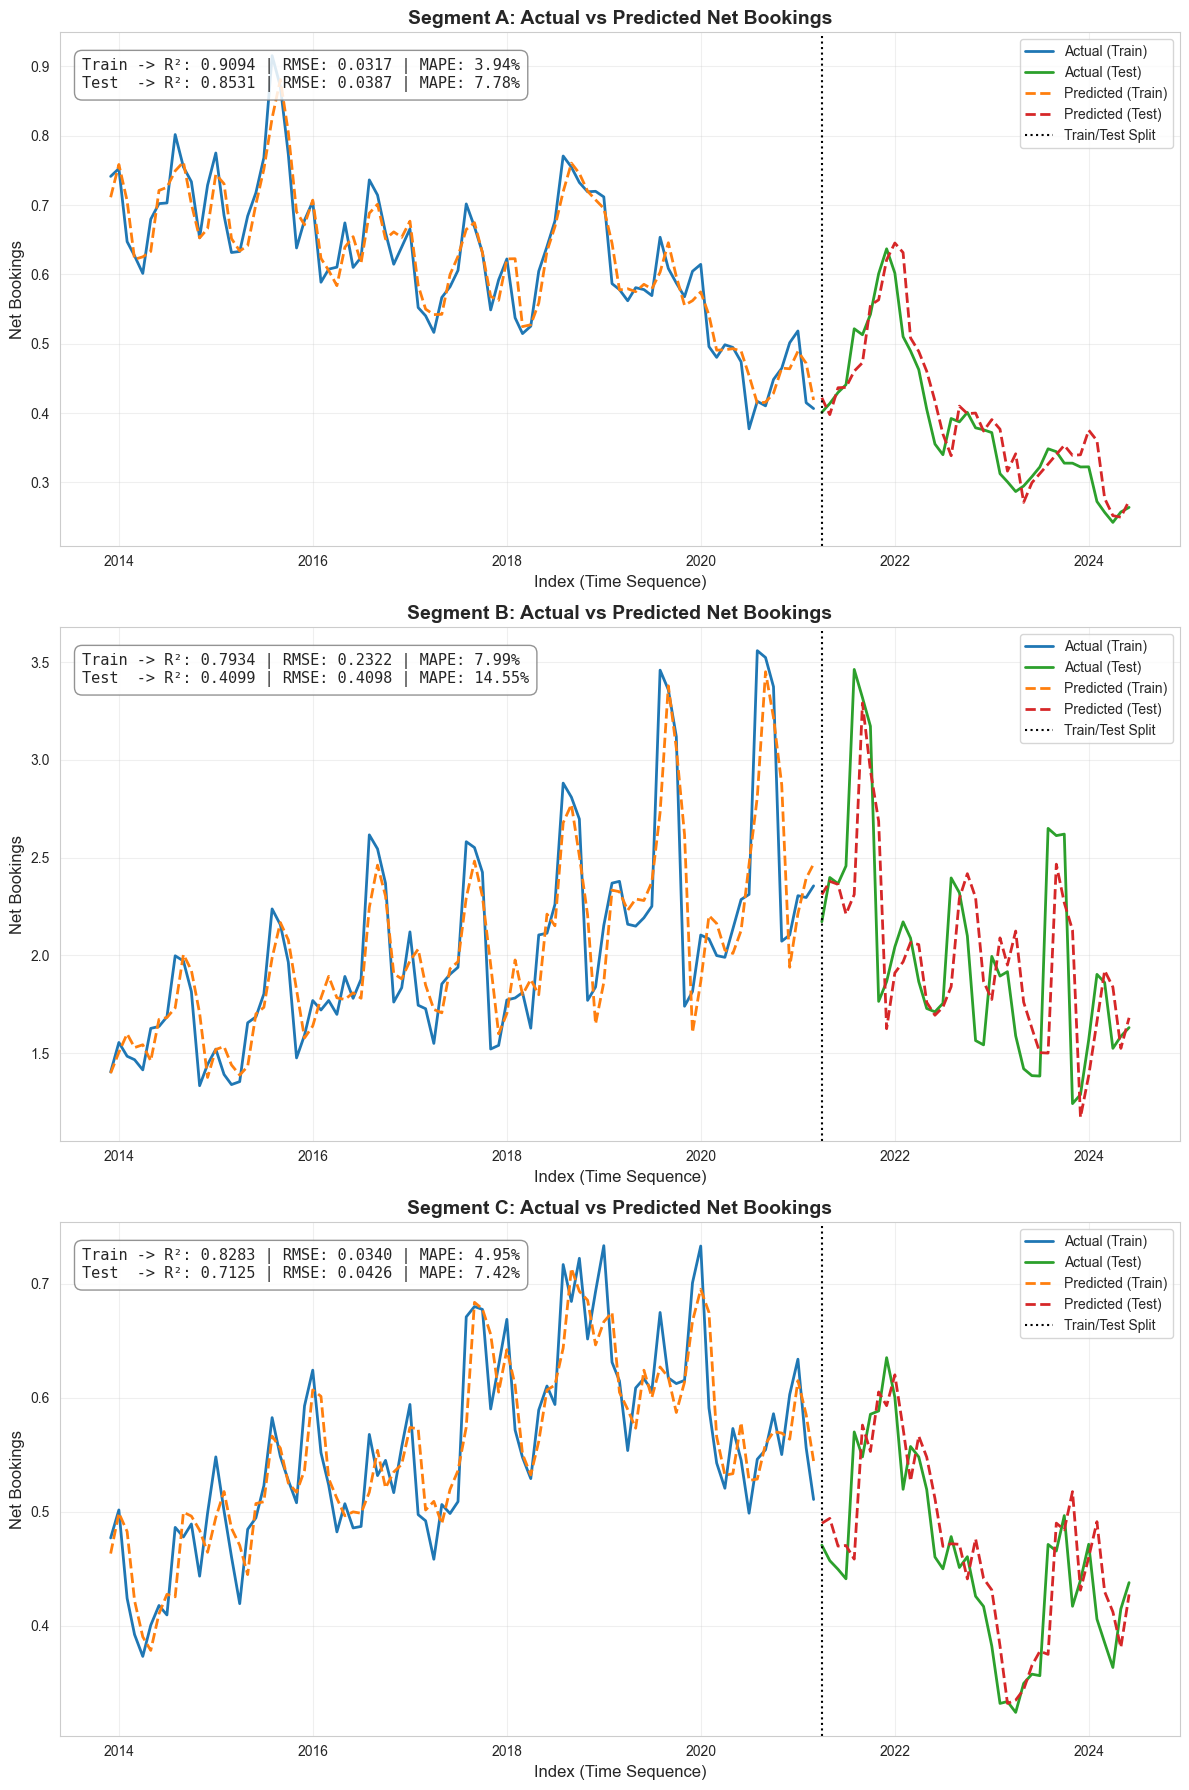

In [18]:
# Mapping the segments to their respective in-memory dataframes
datasets = {
    'A': (train_A_filtered, test_A_filtered),
    'B': (train_B_filtered, test_B_filtered),
    'C': (train_C_filtered, test_C_filtered)
}

# Create a figure with 3 subplots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for idx, (seg, (train_df, test_df)) in enumerate(datasets.items()):
    
    # Make a copy to avoid modifying the original dataframes
    train = train_df.copy()
    test = test_df.copy()
    
    target_col = f'net_bookings_3m | Segment_{seg}'
    lag1_col = f'{target_col}_lag1'
    
    # Identify all 't' target columns to prevent data leakage 
    t_targets = [c for c in train.columns if 'net_bookings_3m' in c and '_lag' not in c]
    
    X_train = train.drop(columns=t_targets)
    y_train_abs = train[target_col]
    
    X_test = test.drop(columns=t_targets)
    y_test_abs = test[target_col]
    
    # Identify the lag1 value
    train_lag1 = train[lag1_col]
    test_lag1 = test[lag1_col]
    
    # 1. DIFFERENCING
    y_train_diff = y_train_abs - train_lag1
    y_test_diff = y_test_abs - test_lag1
    
    train_mask = y_train_diff.notna() & y_train_abs.notna()
    X_train = X_train[train_mask]
    y_train_diff = y_train_diff[train_mask]
    y_train_abs = y_train_abs[train_mask]
    train_lag1 = train_lag1[train_mask]
    
    test_mask = y_test_diff.notna() & y_test_abs.notna()
    X_test = X_test[test_mask]
    y_test_diff = y_test_diff[test_mask]
    y_test_abs = y_test_abs[test_mask]
    test_lag1 = test_lag1[test_mask]
    
    # 2. FEATURE SELECTION
    imputer = SimpleImputer(strategy='mean')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    
    sel_model = GradientBoostingRegressor(random_state=42, max_depth=3)
    sel_model.fit(X_train_imp, y_train_diff)
    importance_df = pd.DataFrame({'Feature': X_train.columns, 'Imp': sel_model.feature_importances_})
    top_10_features = importance_df.sort_values('Imp', ascending=False).head(10)['Feature'].tolist()
    
    # 3. MODEL
    final_model = HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.05,
        max_iter=50,
        max_depth=3,
        min_samples_leaf=10,
        l2_regularization=1.0,
        random_state=42
    )
    
    final_model.fit(X_train[top_10_features], y_train_diff)
    train_diff_preds = final_model.predict(X_train[top_10_features])
    test_diff_preds = final_model.predict(X_test[top_10_features])
    
    # 4. RECONSTRUCTION
    train_preds_abs = train_diff_preds + train_lag1.values
    test_preds_abs = test_diff_preds + test_lag1.values
    
    # 5. METRICS CALCULATION
    train_r2 = r2_score(y_train_abs, train_preds_abs)
    train_rmse = np.sqrt(mean_squared_error(y_train_abs, train_preds_abs))
    train_mape = mean_absolute_percentage_error(y_train_abs, train_preds_abs)
    
    test_r2 = r2_score(y_test_abs, test_preds_abs)
    test_rmse = np.sqrt(mean_squared_error(y_test_abs, test_preds_abs))
    test_mape = mean_absolute_percentage_error(y_test_abs, test_preds_abs)
    
    # 6. PLOTTING
    ax = axes[idx]
    train_idx = y_train_abs.index
    test_idx = y_test_abs.index
    
    ax.plot(train_idx, y_train_abs, label='Actual (Train)', color='#1f77b4', linewidth=2)
    ax.plot(test_idx, y_test_abs, label='Actual (Test)', color='#2ca02c', linewidth=2)
    ax.plot(train_idx, train_preds_abs, label='Predicted (Train)', color='#ff7f0e', linestyle='--', linewidth=2)
    ax.plot(test_idx, test_preds_abs, label='Predicted (Test)', color='#d62728', linestyle='--', linewidth=2)
    ax.axvline(x=test_idx[0], color='black', linestyle=':', label='Train/Test Split')
    
    # Text box for metrics
    metrics_text = (
        f"Train -> R²: {train_r2:.4f} | RMSE: {train_rmse:.4f} | MAPE: {train_mape:.2%}\n"
        f"Test  -> R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAPE: {test_mape:.2%}"
    )
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray')
    ax.text(0.02, 0.95, metrics_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props, fontfamily='monospace')
    
    # Formatting
    ax.set_title(f'Segment {seg}: Actual vs Predicted Net Bookings', fontsize=14, fontweight='bold')
    ax.set_xlabel('Index (Time Sequence)', fontsize=12)
    ax.set_ylabel('Net Bookings', fontsize=12)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
AGGREGATION AND ENTITY-LEVEL EVALUATION LOGIC:
- Implement a segment level forecasting strategy by training individual models for each business segment and aggregating their results to form a global entity-level prediction.
- Execute a standardized modeling pipeline for each segment, including first-order differencing, leakage prevention, and automated feature selection.
- Utilize a Gradient Boosting Regressor to capture non-linear relationships within the top 10 most influential drivers for each segment.
- Reconstruct absolute booking values for each segment by adding predicted changes back to the historical baseline while preserving exact timestamp indexing.
- Consolidate the individual segment forecasts into a single global prediction by summing the time-aligned outputs across all business units.
- Align the aggregated predictions with the actual global entity target to ensure a mathematically valid comparison of performance across the entire timeline.
- Calculate comprehensive evaluation metrics, including R², RMSE, and MAPE, to evaluate the accuracy and reliability of the consolidated forecasting approach.
- Generate a holistic visualization comparing actual global bookings against the aggregated training and testing forecasts to audit model performance at scale.
- Incorporate a centralized metrics summary to give an overview of the model's predictive capabilities.
"""

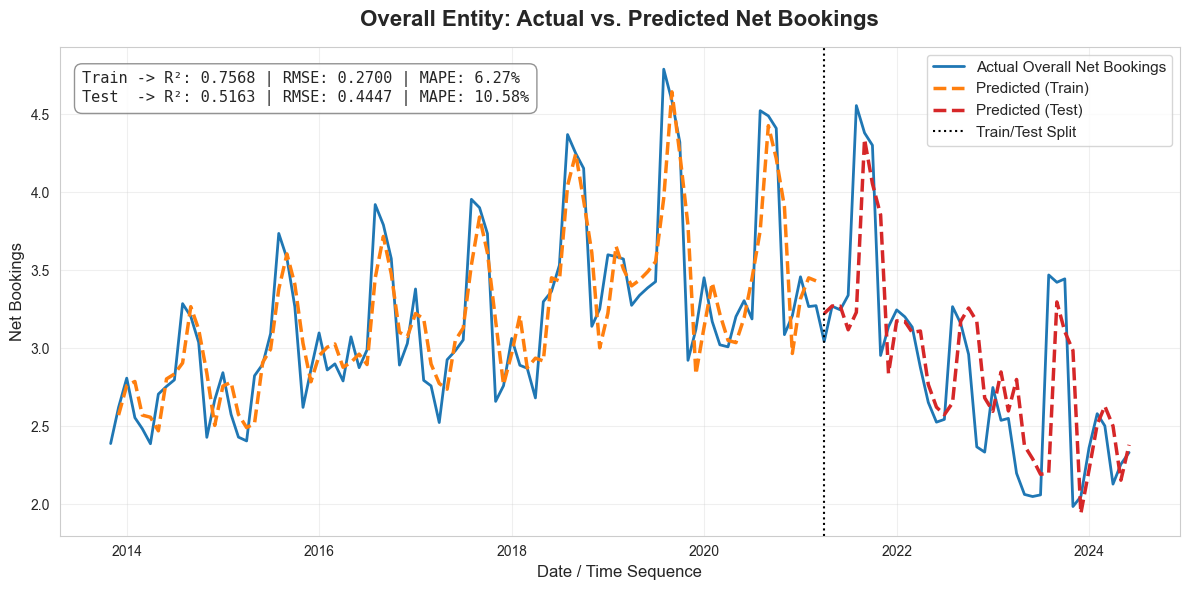

In [19]:
entity_actual = df['net_bookings_3m | Entity']

segments = ['A', 'B', 'C']
train_preds_dict = {}
test_preds_dict = {}

# Using your in-memory datasets
datasets = {
    'A': (train_A_filtered, test_A_filtered),
    'B': (train_B_filtered, test_B_filtered),
    'C': (train_C_filtered, test_C_filtered)
}

for seg, (train_df, test_df) in datasets.items():
    train = train_df.copy()
    test = test_df.copy()
    
    target_col = f'net_bookings_3m | Segment_{seg}'
    lag1_col = f'{target_col}_lag1'
    
    t_targets = [c for c in train.columns if 'net_bookings_3m' in c and '_lag' not in c]
    
    X_train = train.drop(columns=t_targets)
    y_train_abs = train[target_col]
    
    X_test = test.drop(columns=t_targets)
    y_test_abs = test[target_col]
    
    train_lag1 = train[lag1_col]
    test_lag1 = test[lag1_col]
    
    # DIFFERENCING
    y_train_diff = y_train_abs - train_lag1
    y_test_diff = y_test_abs - test_lag1
    
    train_mask = y_train_diff.notna() & y_train_abs.notna()
    X_train_clean = X_train[train_mask]
    y_train_diff_clean = y_train_diff[train_mask]
    train_lag1_clean = train_lag1[train_mask]
    
    test_mask = y_test_diff.notna() & y_test_abs.notna()
    X_test_clean = X_test[test_mask]
    test_lag1_clean = test_lag1[test_mask]
    
    # FEATURE SELECTION
    imputer = SimpleImputer(strategy='mean')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)
    
    sel_model = GradientBoostingRegressor(random_state=42, max_depth=3)
    sel_model.fit(X_train_imp, y_train_diff_clean)
    importance_df = pd.DataFrame({'Feature': X_train_clean.columns, 'Imp': sel_model.feature_importances_})
    top_10_features = importance_df.sort_values('Imp', ascending=False).head(10)['Feature'].tolist()
    
    # CONSTRAINED MODEL
    final_model = HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.05,
        max_iter=50,
        max_depth=3,
        min_samples_leaf=10,
        l2_regularization=1.0,
        random_state=42
    )
    
    final_model.fit(X_train_clean[top_10_features], y_train_diff_clean)
    train_diff_preds = final_model.predict(X_train_clean[top_10_features])
    test_diff_preds = final_model.predict(X_test_clean[top_10_features])
    
    # RECONSTRUCTION
    train_preds_abs = train_diff_preds + train_lag1_clean.values
    test_preds_abs = test_diff_preds + test_lag1_clean.values
    
    # Retain exact index mapping (FIX APPLIED HERE)
    train_preds_dict[seg] = pd.Series(train_preds_abs, index=train.index[train_mask])
    test_preds_dict[seg] = pd.Series(test_preds_abs, index=test.index[test_mask])

# Aggregate Predictions: Sum across Segments
train_pred_entity = pd.DataFrame(train_preds_dict).sum(axis=1)
test_pred_entity = pd.DataFrame(test_preds_dict).sum(axis=1)

# Align the actual Entity Target using the matching indices
y_train_actual_entity = entity_actual.loc[train_pred_entity.index]
y_test_actual_entity = entity_actual.loc[test_pred_entity.index]

# Calculate Overall Metrics
train_r2 = r2_score(y_train_actual_entity, train_pred_entity)
train_rmse = np.sqrt(mean_squared_error(y_train_actual_entity, train_pred_entity))
train_mape = mean_absolute_percentage_error(y_train_actual_entity, train_pred_entity)

test_r2 = r2_score(y_test_actual_entity, test_pred_entity)
test_rmse = np.sqrt(mean_squared_error(y_test_actual_entity, test_pred_entity))
test_mape = mean_absolute_percentage_error(y_test_actual_entity, test_pred_entity)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Actuals (Blue)
ax.plot(entity_actual.index, entity_actual, label='Actual Overall Net Bookings', color='#1f77b4', linewidth=2)

# Plot Predicted Train (Orange) and Test (Red)
ax.plot(train_pred_entity.index, train_pred_entity, label='Predicted (Train)', color='#ff7f0e', linestyle='--', linewidth=2.5)
ax.plot(test_pred_entity.index, test_pred_entity, label='Predicted (Test)', color='#d62728', linestyle='--', linewidth=2.5)

# Split Line
split_index = test_pred_entity.index[0]
ax.axvline(x=split_index, color='black', linestyle=':', label='Train/Test Split')

# Metrics Box
metrics_text = (
    f"Train -> R²: {train_r2:.4f} | RMSE: {train_rmse:.4f} | MAPE: {train_mape:.2%}\n"
    f"Test  -> R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAPE: {test_mape:.2%}"
)
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray')
ax.text(0.02, 0.95, metrics_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

# Formatting
ax.set_title('Overall Entity: Actual vs. Predicted Net Bookings', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date / Time Sequence', fontsize=12)
ax.set_ylabel('Net Bookings', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
ITERATIVE MULTI-STEP FORECASTING AND AGGREGATION LOGIC:
- Establish future time indices and forecast containers to support a three-period projection beyond the existing historical horizon.
- Re-adjust the predictive models using the full historical timeline to capture the most recent market dynamics and trends before forecasting.
- Execute a final feature selection pass on the consolidated dataset to isolate the ten most influential drivers for each business segment.
- Implement forecasting loop that appends future periods and forward-fills external features to maintain a continuous input stream.
- Dynamically reconstruct lagged features at each iteration to incorporate previous predictions as inputs for the subsequent time step.
- Predict the period-over-period change for each future step and add it back to the prior period's baseline to reconstruct the absolute booking scale.
- Synthesize individual segment projections into a total entity forecast.
- Generate comparative time-series visualizations.
- Produce a structured summary table of the next three periods to provide a clear, quantitative view of the expected forecast trajectory.
"""


=== NEXT 3 PERIODS FORECAST ===
Time Step | Segment A | Segment B | Segment C | OVERALL ENTITY
-----------------------------------------------------------------
  T + 1   |      0.26 |      1.80 |      0.46 |           2.52
  T + 2   |      0.26 |      1.93 |      0.47 |           2.66
  T + 3   |      0.26 |      2.04 |      0.49 |           2.79


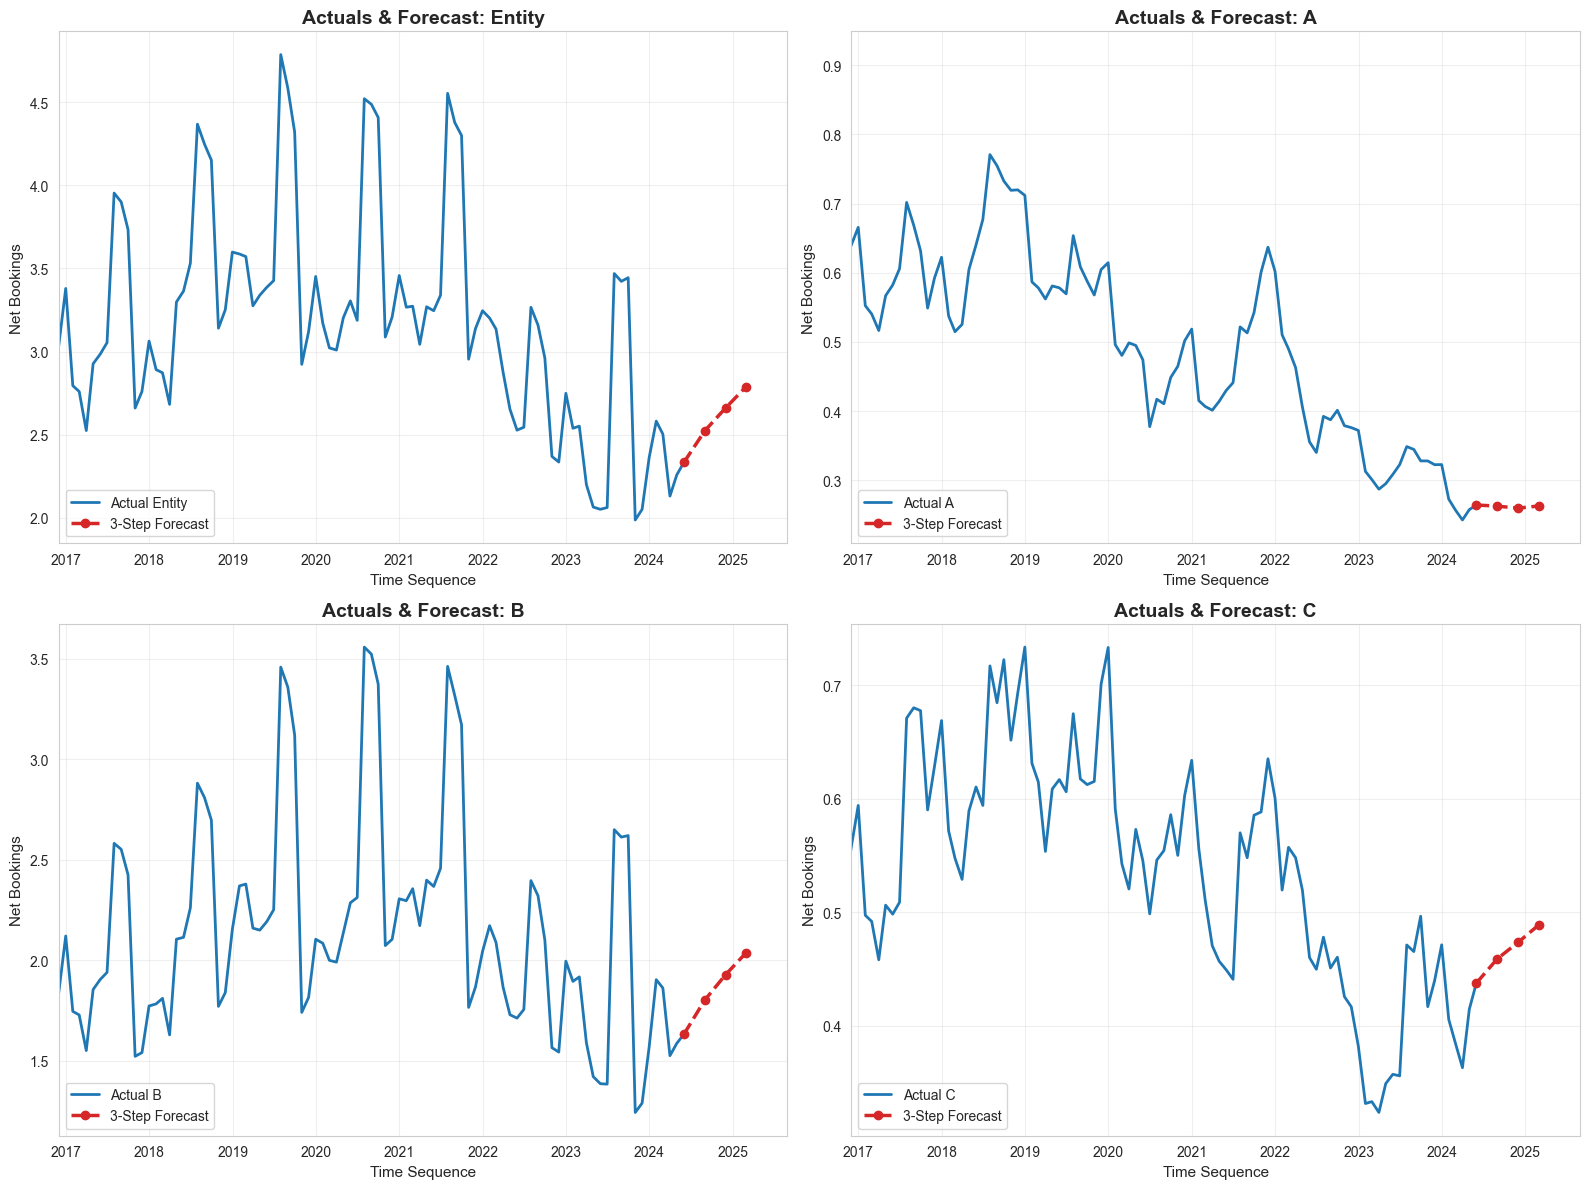

In [20]:
def create_lagged_features(df, n_lags=3):
    lagged_data = [df]
    for lag in range(1, n_lags + 1):
        shifted = df.shift(lag)
        shifted.columns = [f"{col}_lag{lag}" for col in df.columns]
        lagged_data.append(shifted)
    return pd.concat(lagged_data, axis=1)

segments = ['A', 'B', 'C']
datasets = {
    'A': (train_A_filtered, test_A_filtered, df_A),
    'B': (train_B_filtered, test_B_filtered, df_B),
    'C': (train_C_filtered, test_C_filtered, df_C)
}

# Ensure df_orig is loaded with your actual dates/indices if applicable
# df_orig = pd.read_csv('bookings_data.csv')
entity_actual = df['net_bookings_3m | Entity']

future_forecasts = {'A': [], 'B': [], 'C': [], 'Entity': []}
hist_actuals = {'A': None, 'B': None, 'C': None}

# FIX 1: Dynamically handle Datetime vs Integer indexing for future plotting
last_actual_idx = entity_actual.index[-1]
if isinstance(last_actual_idx, pd.Timestamp):
    # Add 3 months per step since it's a 3m forecast
    future_indices = [last_actual_idx + pd.DateOffset(months=3 * (i + 1)) for i in range(3)]
else:
    future_indices = [last_actual_idx + 1, last_actual_idx + 2, last_actual_idx + 3]

for seg, (train_df, test_df, df_base) in datasets.items():
    # 1. RETRAIN ON THE FULL TIMELINE
    full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
    
    target_col = f'net_bookings_3m | Segment_{seg}'
    lag1_col = f'{target_col}_lag1'
    
    hist_actuals[seg] = full_df[target_col].copy()
    # Map back original indices to hist_actuals for accurate plotting
    hist_actuals[seg].index = df_base.index 
    
    t_targets = [c for c in full_df.columns if 'net_bookings_3m' in c and '_lag' not in c]
    
    X_full = full_df.drop(columns=t_targets)
    y_full_abs = full_df[target_col]
    full_lag1 = full_df[lag1_col]
    
    y_full_diff = y_full_abs - full_lag1
    full_mask = y_full_diff.notna() & y_full_abs.notna()
    
    X_full_clean = X_full[full_mask]
    y_full_diff_clean = y_full_diff[full_mask]
    
    # Feature Selection on Full Data
    imputer = SimpleImputer(strategy='mean')
    X_full_imp = pd.DataFrame(imputer.fit_transform(X_full_clean), columns=X_full_clean.columns)
    
    sel_model = GradientBoostingRegressor(random_state=42, max_depth=3)
    sel_model.fit(X_full_imp, y_full_diff_clean)
    
    importance_df = pd.DataFrame({'Feature': X_full_clean.columns, 'Imp': sel_model.feature_importances_})
    top_10_features = importance_df.sort_values('Imp', ascending=False).head(10)['Feature'].tolist()
    
    # Final Model
    final_model = HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.05,
        max_iter=50,
        max_depth=3,
        min_samples_leaf=10,
        l2_regularization=1.0,
        random_state=42
    )
    final_model.fit(X_full_clean[top_10_features], y_full_diff_clean)
    
    # 2. ITERATIVE 3-STEP FORECAST
    current_df = df_base.copy()
    
    for step in range(3):
        # FIX 2: Correctly append Datetime vs Integer empty row
        last_idx = current_df.index[-1]
        if isinstance(last_idx, pd.Timestamp):
            next_idx = last_idx + pd.DateOffset(months=3)
        else:
            next_idx = last_idx + 1
            
        empty_row = pd.DataFrame(index=[next_idx], columns=current_df.columns)
        current_df = pd.concat([current_df, empty_row])
        
        # Forward fill external features
        cols_to_ffill = [c for c in current_df.columns if c != target_col]
        current_df[cols_to_ffill] = current_df[cols_to_ffill].ffill()
        
        # Recreate lag features dynamically
        df_lagged_ext = create_lagged_features(current_df, n_lags=3)
        
        # Extract the new future row
        future_row = df_lagged_ext.iloc[[-1]]
        X_future = future_row[top_10_features]
        lag1_val = future_row[lag1_col].values[0]
        
        # Predict
        future_diff_pred = final_model.predict(X_future)[0]
        future_abs_pred = future_diff_pred + lag1_val
        
        # Update current_df with prediction
        current_df.loc[current_df.index[-1], target_col] = future_abs_pred
        future_forecasts[seg].append(future_abs_pred)

# Aggregate predictions for the overall Entity
future_forecasts['Entity'] = [
    future_forecasts['A'][i] + future_forecasts['B'][i] + future_forecasts['C'][i] 
    for i in range(3)
]

# Print values
print("\n=== NEXT 3 PERIODS FORECAST ===")
print("Time Step | Segment A | Segment B | Segment C | OVERALL ENTITY")
print("-" * 65)
for i in range(3):
    step_label = f"T + {i+1}"
    print(f"  {step_label}   | {future_forecasts['A'][i]:9.2f} | {future_forecasts['B'][i]:9.2f} | {future_forecasts['C'][i]:9.2f} | {future_forecasts['Entity'][i]:14.2f}")

# 3. PLOTTING THE FORECASTS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_targets = [
    ('Entity', entity_actual),
    ('A', hist_actuals['A']),
    ('B', hist_actuals['B']),
    ('C', hist_actuals['C'])
]

for idx, (name, actual_series) in enumerate(plot_targets):
    ax = axes[idx]
    
    # Historical actuals
    ax.plot(actual_series.index, actual_series, label=f'Actual {name}', color='#1f77b4', linewidth=2)
    
    # Connect forecast to actuals
    last_actual_value = actual_series.iloc[-1]
    forecast_indices = [actual_series.index[-1]] + future_indices
    forecast_values = [last_actual_value] + future_forecasts[name]
    
    # Plot forecast
    ax.plot(forecast_indices, forecast_values, label='3-Step Forecast', color='#d62728', linestyle='--', marker='o', linewidth=2.5)
    
    ax.set_title(f'Actuals & Forecast: {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Sequence', fontsize=11)
    ax.set_ylabel('Net Bookings', fontsize=11)
    
    # Zoom in on the recent past to see the forecast clearly
    if isinstance(actual_series.index[-1], pd.Timestamp):
        min_x_display = actual_series.index[-1] - pd.DateOffset(months=30 * 3) # Approx last 30 quarters
    else:
        min_x_display = max(0, actual_series.index[-1] - 30)
        
    ax.set_xlim(min_x_display, future_indices[-1] + (pd.DateOffset(months=6) if isinstance(actual_series.index[-1], pd.Timestamp) else 2))
    
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()